In [2]:
# Notebook 1: Dataset → DataFrame → EDA → Tokenization.

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [4]:
dataset = load_dataset("emotion")

dataset

Using the latest cached version of the dataset since emotion couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'split' at C:\Users\vinna\.cache\huggingface\datasets\emotion\split\0.0.0\cab853a1dbdf4c42c2b3ef2173804746df8825fe (last modified on Sat Jun 13 12:03:48 2026).


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [5]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [6]:
dataset["train"][0]

{'text': 'i didnt feel humiliated', 'label': 0}

In [7]:
dataset["train"].features

{'text': Value(dtype='string', id=None),
 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'], id=None)}

In [8]:
train_df = dataset["train"].to_pandas()
valid_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

train_df

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3
...,...,...
15995,i just had a very brief time in the beanbag an...,0
15996,i am now turning and i feel pathetic that i am...,0
15997,i feel strong and good overall,1
15998,i feel like this was such a rude comment and i...,3


In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    16000 non-null  object
 1   label   16000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 250.1+ KB


In [10]:
label_names = dataset["train"].features["label"].names

train_df["label_name"] = train_df["label"].apply(lambda x: label_names[x])

train_df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [11]:
train_df["label_name"].value_counts()

label_name
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

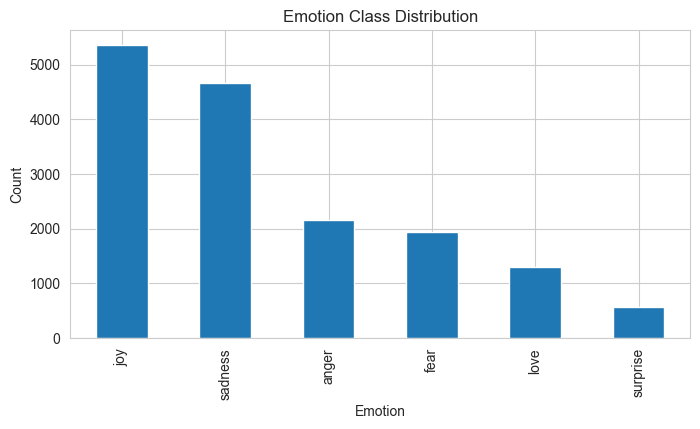

In [12]:
plt.figure(figsize=(8, 4))

train_df["label_name"].value_counts().plot(kind="bar")

plt.title("Emotion Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")

plt.show()

In [13]:
train_df["words_per_text"] = train_df["text"].str.split().apply(len)

train_df[["text", "words_per_text"]].head()

,text,words_per_text
0,i didnt feel humiliated,4
1,i can go from feeling so hopeless to so damned...,21
2,im grabbing a minute to post i feel greedy wrong,10
3,i am ever feeling nostalgic about the fireplac...,18
4,i am feeling grouchy,4


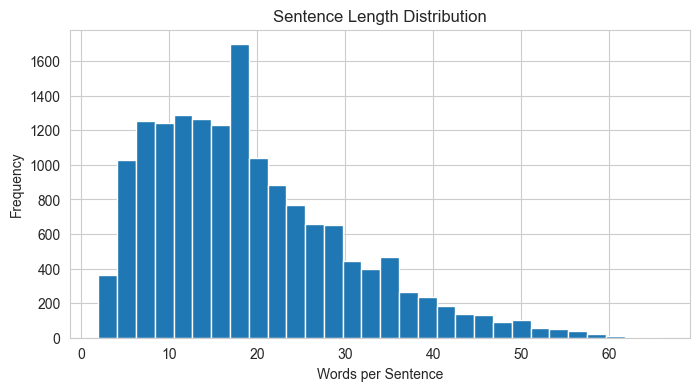

In [14]:
plt.figure(figsize=(8, 4))

train_df["words_per_text"].hist(bins=30)

plt.xlabel("Words per Sentence")
plt.ylabel("Frequency")
plt.title("Sentence Length Distribution")

plt.show()

In [15]:
text = "I hated the plot, but the acting was phenomenal!"

char_tokens = list(text)

print(char_tokens)

['I', ' ', 'h', 'a', 't', 'e', 'd', ' ', 't', 'h', 'e', ' ', 'p', 'l', 'o', 't', ',', ' ', 'b', 'u', 't', ' ', 't', 'h', 'e', ' ', 'a', 'c', 't', 'i', 'n', 'g', ' ', 'w', 'a', 's', ' ', 'p', 'h', 'e', 'n', 'o', 'm', 'e', 'n', 'a', 'l', '!']


In [16]:
word_tokens = text.split()

print(word_tokens)

['I', 'hated', 'the', 'plot,', 'but', 'the', 'acting', 'was', 'phenomenal!']


In [17]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
tokenizer

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


DistilBertTokenizerFast(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}

In [18]:
subword_tokens = tokenizer.tokenize(text)

print(subword_tokens)

['i', 'hated', 'the', 'plot', ',', 'but', 'the', 'acting', 'was', 'phenomena', '##l', '!']


In [19]:
token_ids = tokenizer.convert_tokens_to_ids(subword_tokens)

for token, idx in zip(subword_tokens, token_ids):
    print(f"{token:15} -> {idx}")

i               -> 1045
hated           -> 6283
the             -> 1996
plot            -> 5436
,               -> 1010
but             -> 2021
the             -> 1996
acting          -> 3772
was             -> 2001
phenomena       -> 13352
##l             -> 2140
!               -> 999


In [20]:
encoding = tokenizer(text, padding=True, truncation=True, return_attention_mask=True)

print(encoding)

{'input_ids': [101, 1045, 6283, 1996, 5436, 1010, 2021, 1996, 3772, 2001, 13352, 2140, 999, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [21]:
decoded = tokenizer.decode(encoding["input_ids"])

print(decoded)

[CLS] i hated the plot, but the acting was phenomenal! [SEP]


In [22]:
def tokenize(batch):
    return tokenizer(
        batch["text"], truncation=True, padding="max_length", max_length=64
    )


tokenized_dataset = dataset.map(tokenize, batched=True)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [23]:
tokenized_dataset["train"][0]

{'text': 'i didnt feel humiliated',
 'label': 0,
 'input_ids': [101,
  1045,
  2134,
  2102,
  2514,
  26608,
  102,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'attention_mask': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0]}

In [24]:
documents = [
    "I love this movie",
    "This movie is amazing",
    "I hate this movie",
    "This movie is terrible",
]

labels = ["Positive", "Positive", "Negative", "Negative"]

for doc, label in zip(documents, labels):
    print(f"{label:10} : {doc}")

Positive   : I love this movie
Positive   : This movie is amazing
Negative   : I hate this movie
Negative   : This movie is terrible


In [25]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X_bow = vectorizer.fit_transform(documents)

print("Vocabulary:")
print(vectorizer.vocabulary_)

Vocabulary:
{'love': 3, 'this': 6, 'movie': 4, 'is': 2, 'amazing': 0, 'hate': 1, 'terrible': 5}


In [26]:
import pandas as pd

bow_df = pd.DataFrame(X_bow.toarray(), columns=vectorizer.get_feature_names_out())

bow_df

,amazing,hate,is,love,movie,terrible,this
0,0,0,0,1,1,0,1
1,1,0,1,0,1,0,1
2,0,1,0,0,1,0,1
3,0,0,1,0,1,1,1


In [27]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

cv = CountVectorizer()

counts = cv.fit_transform(documents)

tf = counts.toarray() / counts.toarray().sum(axis=1, keepdims=True)

tf_df = pd.DataFrame(np.round(tf, 3), columns=cv.get_feature_names_out())

tf_df

,amazing,hate,is,love,movie,terrible,this
0,0.00,0.000,0.00,0.333,0.333,0.00,0.333
1,0.25,0.000,0.25,0.000,0.250,0.00,0.250
2,0.00,0.333,0.00,0.000,0.333,0.00,0.333
3,0.00,0.000,0.25,0.000,0.250,0.25,0.250


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()

X_tfidf = tfidf_vectorizer.fit_transform(documents)

tfidf_df = pd.DataFrame(
    X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out()
)

tfidf_df.round(3)

,amazing,hate,is,love,movie,terrible,this
0,0.000,0.000,0.000,0.805,0.420,0.000,0.420
1,0.679,0.000,0.536,0.000,0.355,0.000,0.355
2,0.000,0.805,0.000,0.000,0.420,0.000,0.420
3,0.000,0.000,0.536,0.000,0.355,0.679,0.355


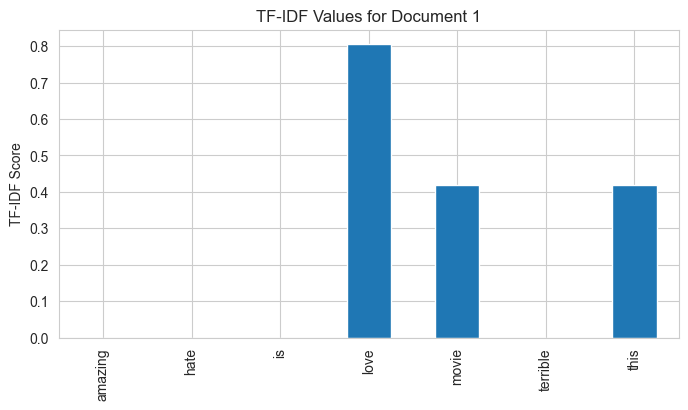

In [29]:
import matplotlib.pyplot as plt

sample_doc = tfidf_df.iloc[0]

sample_doc.plot(kind="bar", figsize=(8, 4), title="TF-IDF Values for Document 1")

plt.ylabel("TF-IDF Score")
plt.show()

In [30]:
from sklearn.linear_model import LogisticRegression

y = [1, 1, 0, 0]  # Positive  # Negative

model = LogisticRegression()

model.fit(X_tfidf, y)

print("Training Completed!")

Training Completed!


In [31]:
test_sentence = ["This movie is amazing"]

X_test = tfidf_vectorizer.transform(test_sentence)

prediction = model.predict(X_test)

print(prediction)

[1]


In [32]:
probabilities = model.predict_proba(X_test)

print(probabilities)

[[0.44843176 0.55156824]]


In [33]:
# while True:

#     text = input("Enter a movie review (or 'quit'): ")

#     if text.lower() == "quit":
#         break

#     x = tfidf_vectorizer.transform([text])

#     pred = model.predict(x)[0]
#     probs = model.predict_proba(x)[0]

#     label = "Positive" if pred == 1 else "Negative"

#     print("\nPrediction:", label)
#     print("Confidence:")
#     print(f"Negative: {probs[0]*100:.2f}%")
#     print(f"Positive: {probs[1]*100:.2f}%")
#     print("-" * 40)

In [34]:
feature_names = tfidf_vectorizer.get_feature_names_out()

coefficients = model.coef_[0]

coef_df = pd.DataFrame({"word": feature_names, "weight": coefficients})

coef_df.sort_values(by="weight", ascending=False).head(10)

,word,weight
3,love,3.465742e-01
0,amazing,3.046784e-01
4,movie,2.629480e-17
6,this,2.629480e-17
2,is,0.000000e+00
5,terrible,-3.046784e-01
1,hate,-3.465742e-01


In [35]:
coef_df.sort_values(by="weight", ascending=False)

,word,weight
3,love,3.465742e-01
0,amazing,3.046784e-01
4,movie,2.629480e-17
6,this,2.629480e-17
2,is,0.000000e+00
5,terrible,-3.046784e-01
1,hate,-3.465742e-01


In [36]:
coef_df.sort_values(by="weight")

,word,weight
1,hate,-3.465742e-01
5,terrible,-3.046784e-01
2,is,0.000000e+00
4,movie,2.629480e-17
6,this,2.629480e-17
0,amazing,3.046784e-01
3,love,3.465742e-01


In [37]:
from sklearn.metrics import classification_report

predictions = model.predict(X_tfidf)

print(classification_report(y, predictions, target_names=["Negative", "Positive"]))

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         2
    Positive       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, predictions)

print(cm)

[[2 0]
 [0 2]]


In [39]:
from datasets import load_dataset

dataset = load_dataset("emotion")

train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

Using the latest cached version of the dataset since emotion couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'split' at C:\Users\vinna\.cache\huggingface\datasets\emotion\split\0.0.0\cab853a1dbdf4c42c2b3ef2173804746df8825fe (last modified on Sat Jun 13 12:09:55 2026).


In [40]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train = tfidf_vectorizer.fit_transform(train_df["text"])

X_test = tfidf_vectorizer.transform(test_df["text"])

y_train = train_df["label"]
y_test = test_df["label"]

In [41]:
clf = LogisticRegression(max_iter=1000)

clf.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [42]:
from sklearn.metrics import accuracy_score

preds = clf.predict(X_test)

accuracy = accuracy_score(y_test, preds)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8690
